# EDA - Dominio Territorial do Crime Organizado (CompStat Rio)

Este notebook explora a camada de **dominio territorial** mapeada pelo GENI/UFF e parceiros: poligonos atribuidos a faccoes do crime organizado no estado do Rio de Janeiro.

**O que e uma faccao territorial?** Sao grupos criminosos que exercem controle de fato sobre uma area geografica - regulam acesso, cobram taxas, controlam mercados ilicitos e disputam fronteiras com rivais. As quatro faccoes presentes no dataset:

- **CV** (Comando Vermelho) - faccao do trafico, historicamente dominante em varias comunidades da Zona Norte.
- **TCP** (Terceiro Comando Puro) - dissidencia do CV, foco em Zona Norte/Oeste.
- **ADA** (Amigos dos Amigos) - faccao menor, mais presente em areas especificas.
- **Milicia** - grupos paramilitares (ex-policiais, bombeiros, etc.) que controlam principalmente a Zona Oeste.

**Por que essa camada importa pro CompStat Rio?** O dominio faccional condiciona:
- **Modus operandi** do crime (roubo em area de milicia tem padrao diferente de area de CV).
- **Rotas de fuga** apos a ocorrencia - bandidos tendem a se evadir para territorio "amigo".
- **Fronteiras quentes** - bordas entre faccoes rivais sao zonas de disputa e atritos.
- **Estrategia de patrulhamento** - operacoes em territorio dominado por uma faccao tem riscos especificos.

E insumo critico do **Desafio Extra 2 - Migracao do Crime no Territorio**: quando uma operacao policial expulsa criminosos de uma area, eles tendem a se reorganizar dentro do dominio da mesma faccao.

**Escopo dos dados:** 1.628 poligonos cobrindo o **estado inteiro do RJ** (nao so o municipio), em WKT/EPSG:4326. Vamos filtrar para o bbox municipal antes de cruzar com as 8 areas da Forca Municipal.


In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('MPLCONFIGDIR', os.path.join(os.environ.get('TMPDIR', '/tmp'), 'matplotlib'))
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd
from shapely import wkt

pd.set_option('display.max_rows', 25)
pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

REPO = '/Users/alexandreguimaraes/Documents/Personal Projects/claude_impact/claude_impact_lab_compstat_rio'
CSV_PATH = f'{REPO}/dados/outros dados/dominio_territorial - Extração 1.csv'
SHP_PATH = f'{REPO}/sh_area_forca/areas_forca_municipal.shp'

# Faction colors (kept consistent across the notebook)
FACTION_COLORS = {
    'CV':       '#d62728',  # red
    'TCP':      '#1f77b4',  # blue
    'ADA':      '#2ca02c',  # green
    'Milicia':  '#9467bd',  # purple
}

# Rio municipality bounding box (rough)
RIO_BBOX = dict(minx=-43.85, maxx=-43.10, miny=-23.10, maxy=-22.70)

print('CSV:', CSV_PATH)
print('SHP:', SHP_PATH)


CSV: /Users/alexandreguimaraes/Documents/Personal Projects/claude_impact/claude_impact_lab_compstat_rio/dados/outros dados/dominio_territorial - Extração 1.csv
SHP: /Users/alexandreguimaraes/Documents/Personal Projects/claude_impact/claude_impact_lab_compstat_rio/sh_area_forca/areas_forca_municipal.shp


## 2. Carregamento e parse do WKT

Carregamos o CSV, convertemos a coluna `geometria` (WKT POLYGON) para objetos Shapely e atribuimos o CRS **EPSG:4326** (lat/long WGS84). Em seguida checamos validade geometrica - poligonos invalidos (self-intersect, etc.) sao corrigidos com `buffer(0)`.

In [2]:
df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
print('Colunas:', list(df.columns))
df.head(3)


Shape: (1628, 3)
Colunas: ['nome_territorio', 'dominio_orcrim', 'geometria']


,nome_territorio,dominio_orcrim,geometria
0,MORRO SANTANA,ADA,"POLYGON((-41.7902341999999 -22.3715415999999, -41.7890968999999 -22.3724941, -41.7887964999999 -22.3736648, -41.7864577 -22.3743393999999, -41.7861786999999 -22.3720432, -41.7856207999999 -22.3718843999999, -41.7858138999999 -22.3707479, -41.7860499999999 -22.3697955, -41.7882600999999 -22.3692397999999, -41.7898264999999 -22.3698747999999, -41.7904273 -22.3699541999999, -41.7902341999999 -22.3715415999999))"
1,MORRO DO CARVÃO,ADA,"POLYGON((-41.7751943 -22.3900022999999, -41.7756555999999 -22.3886234, -41.7753552 -22.3875717999999, -41.7748831 -22.3871452999999, -41.7752907999999 -22.3869965, -41.7750761999999 -22.3851314999999, -41.7766319 -22.3855579999999, -41.7790137 -22.3847941999999, -41.778488 -22.3859747, -41.7779623 -22.3872544, -41.7774044 -22.3884348999999, -41.777501 -22.3899923, -41.7772970999999 -22.3908256, -41.7765461 -22.3911927, -41.7759237999999 -22.3911232, -41.7751943 -22.3900022999999))"
2,PARQUE SAO MATEUS,ADA,"POLYGON((-41.3102325 -21.7165644, -41.3091166999999 -21.7150293999999, -41.3088806 -21.7138533, -41.3095029 -21.7138931, -41.3097389 -21.7143715999999, -41.3107689 -21.7142918, -41.3116701 -21.71485, -41.3128073999999 -21.7146506999999, -41.3141163 -21.7141124, -41.3150603999999 -21.7148101999999, -41.3157256 -21.7146107999999, -41.3165625 -21.7148301, -41.3171632999999 -21.7142918, -41.3176568 -21.7142519999999, -41.3177211999999 -21.7149896, -41.3179572 -21.7165046, -41.3185151 -21.7166242, -41.3187296999999 -21.7169231999999, -41.3184077999999 -21.717302, -41.3122923999999 -21.718518, -41.3102325 -21.7165644))"


In [3]:
# Parse WKT -> Shapely geometries
geom = gpd.GeoSeries.from_wkt(df['geometria'], crs='EPSG:4326')
gdf = gpd.GeoDataFrame(df.drop(columns=['geometria']), geometry=geom, crs='EPSG:4326')

# Normalize faction labels (handle accented Milícia variants)
gdf['dominio_orcrim'] = gdf['dominio_orcrim'].astype(str).str.strip()
gdf['dominio_orcrim'] = gdf['dominio_orcrim'].replace({
    'Milícia': 'Milicia', 'milicia': 'Milicia', 'MILICIA': 'Milicia',
})

# Validity checks
n_total = len(gdf)
n_valid = gdf.geometry.is_valid.sum()
n_invalid = n_total - n_valid
print(f'Poligonos: {n_total} | validos: {n_valid} | invalidos: {n_invalid}')

if n_invalid > 0:
    gdf['geometry'] = gdf.geometry.buffer(0)
    print('Corrigidos com buffer(0). Validos agora:', gdf.geometry.is_valid.sum())

gdf.head(3)


Poligonos: 1628 | validos: 1628 | invalidos: 0


,nome_territorio,dominio_orcrim,geometry
0,MORRO SANTANA,ADA,"POLYGON ((-41.79023 -22.37154, -41.7891 -22.37249, -41.7888 -22.37366, -41.78646 -22.37434, -41.78618 -22.37204, -41.78562 -22.37188, -41.78581 -22.37075, -41.78605 -22.3698, -41.78826 -22.36924, -41.78983 -22.36987, -41.79043 -22.36995, -41.79023 -22.37154))"
1,MORRO DO CARVÃO,ADA,"POLYGON ((-41.77519 -22.39, -41.77566 -22.38862, -41.77536 -22.38757, -41.77488 -22.38715, -41.77529 -22.387, -41.77508 -22.38513, -41.77663 -22.38556, -41.77901 -22.38479, -41.77849 -22.38597, -41.77796 -22.38725, -41.7774 -22.38843, -41.7775 -22.38999, -41.7773 -22.39083, -41.77655 -22.39119, -41.77592 -22.39112, -41.77519 -22.39))"
2,PARQUE SAO MATEUS,ADA,"POLYGON ((-41.31023 -21.71656, -41.30912 -21.71503, -41.30888 -21.71385, -41.3095 -21.71389, -41.30974 -21.71437, -41.31077 -21.71429, -41.31167 -21.71485, -41.31281 -21.71465, -41.31412 -21.71411, -41.31506 -21.71481, -41.31573 -21.71461, -41.31656 -21.71483, -41.31716 -21.71429, -41.31766 -21.71425, -41.31772 -21.71499, -41.31796 -21.7165, -41.31852 -21.71662, -41.31873 -21.71692, -41.31841 -21.7173, -41.31229 -21.71852, -41.31023 -21.71656))"


## 3. Contagem por faccao (estado inteiro)

Visao global: quantos poligonos cada faccao controla no recorte estadual completo (1.628 no total).

In [4]:
counts = gdf['dominio_orcrim'].value_counts()
print('Total:', counts.sum())
counts


Total: 1628


,count
dominio_orcrim,
CV,903
Milicia,423
TCP,229
ADA,73


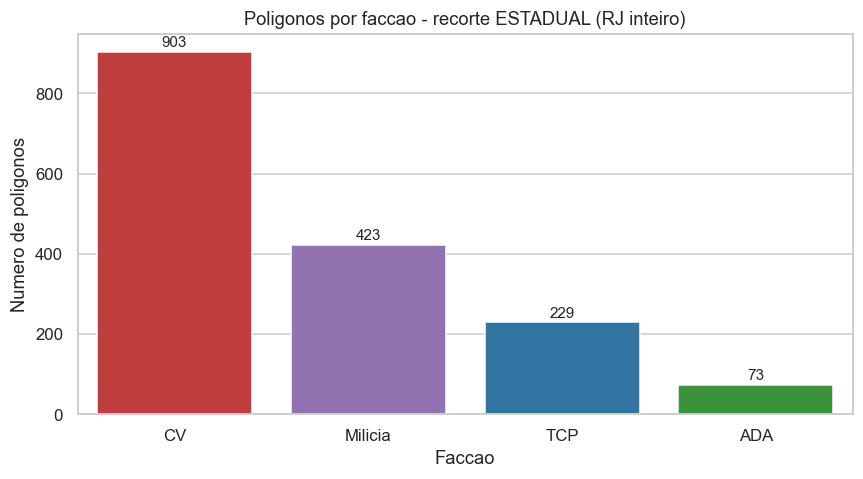

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = counts.index.tolist()
colors = [FACTION_COLORS.get(f, '#888888') for f in order]
sns.barplot(x=order, y=counts.values, ax=ax, palette=colors)
for i, v in enumerate(counts.values):
    ax.text(i, v + 12, f'{int(v):,}', ha='center', fontsize=10)
ax.set_title('Poligonos por faccao - recorte ESTADUAL (RJ inteiro)')
ax.set_xlabel('Faccao'); ax.set_ylabel('Numero de poligonos')
plt.tight_layout(); plt.show()


## 4. Filtro geografico - estado vs municipio do Rio

**GOTCHA IMPORTANTE:** o dataset cobre o **estado inteiro** do RJ. Muitos poligonos estao no norte fluminense (lat ~-21.7, long ~-41.3), longe da cidade do Rio. Para analises que envolvem as 8 areas da Forca Municipal, precisamos filtrar pelo **bbox da cidade**.

In [6]:
# Use polygon centroid to decide membership in Rio bbox
cent = gdf.geometry.centroid
in_rio = (cent.x.between(RIO_BBOX['minx'], RIO_BBOX['maxx']) &
          cent.y.between(RIO_BBOX['miny'], RIO_BBOX['maxy']))
gdf['in_rio'] = in_rio.values

comp = pd.DataFrame({
    'estadual':  gdf['dominio_orcrim'].value_counts(),
    'rio_only':  gdf.loc[gdf['in_rio'], 'dominio_orcrim'].value_counts(),
}).fillna(0).astype(int)
comp['pct_rio_do_total'] = (comp['rio_only'] / comp['estadual'] * 100).round(1)
comp.loc['TOTAL'] = [comp['estadual'].sum(), comp['rio_only'].sum(),
                    round(comp['rio_only'].sum() / comp['estadual'].sum() * 100, 1)]
comp


,estadual,rio_only,pct_rio_do_total
dominio_orcrim,,,
CV,903.0,583.0,64.6
Milicia,423.0,391.0,92.4
TCP,229.0,166.0,72.5
ADA,73.0,24.0,32.9
TOTAL,1628.0,1164.0,71.5


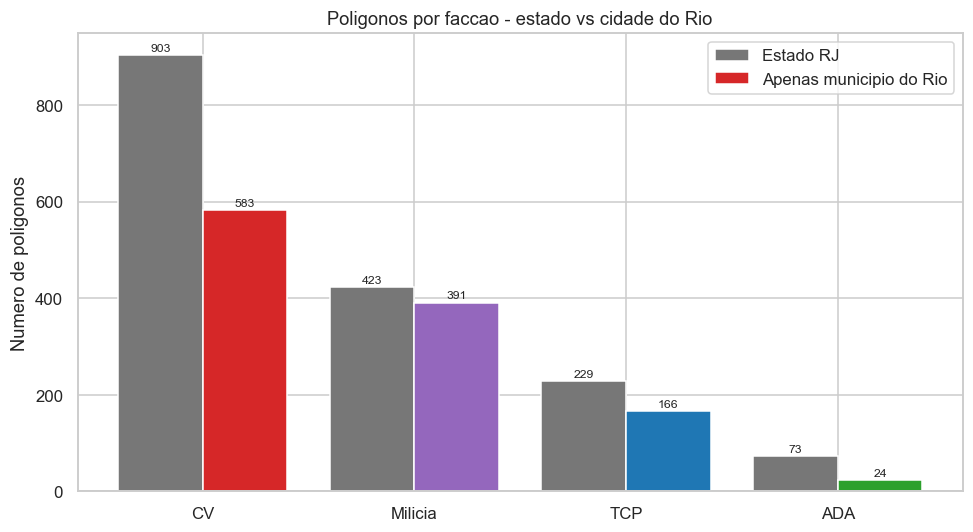

In [7]:
# Side-by-side bar comparing state vs city counts
fig, ax = plt.subplots(figsize=(9, 5))
factions = [f for f in comp.index if f != 'TOTAL']
x = np.arange(len(factions))
w = 0.4
ax.bar(x - w/2, comp.loc[factions, 'estadual'],  width=w, label='Estado RJ', color='#777')
ax.bar(x + w/2, comp.loc[factions, 'rio_only'],  width=w, label='Apenas municipio do Rio',
       color=[FACTION_COLORS.get(f, '#888') for f in factions])
ax.set_xticks(x); ax.set_xticklabels(factions)
ax.set_title('Poligonos por faccao - estado vs cidade do Rio')
ax.set_ylabel('Numero de poligonos')
ax.legend()
for i, f in enumerate(factions):
    ax.text(i - w/2, comp.loc[f, 'estadual'] + 8,  f"{int(comp.loc[f, 'estadual']):,}",  ha='center', fontsize=8)
    ax.text(i + w/2, comp.loc[f, 'rio_only'] + 8,  f"{int(comp.loc[f, 'rio_only']):,}",  ha='center', fontsize=8)
plt.tight_layout(); plt.show()


A diferenca entre o total estadual e o recorte municipal e enorme - boa parte dos poligonos esta fora da cidade do Rio. As proximas analises de area, sobreposicao com FM e mapa usam **somente o subset municipal**.

In [8]:
gdf_rio = gdf[gdf['in_rio']].copy().reset_index(drop=True)
print('Poligonos no municipio do Rio:', len(gdf_rio))


Poligonos no municipio do Rio: 1164


## 5. Area dos poligonos por faccao (km^2)

Para medir area em km^2, reprojetamos para **EPSG:31983** (SIRGAS 2000 / UTM 23S - sistema metrico apropriado para o RJ). Mostramos:
- **boxplot** da area dos poligonos individuais por faccao (algumas faccoes operam em mini-territorios, outras em areas maiores);
- **total km^2 controlado** por faccao no municipio.

In [9]:
gdf_rio_m = gdf_rio.to_crs(epsg=31983).copy()
gdf_rio_m['area_km2'] = gdf_rio_m.geometry.area / 1e6
gdf_rio['area_km2'] = gdf_rio_m['area_km2'].values

by_fac = gdf_rio.groupby('dominio_orcrim')['area_km2'].agg(['count', 'sum', 'mean', 'median', 'max']).round(3)
by_fac = by_fac.rename(columns={'count': 'n_poligonos', 'sum': 'total_km2',
                                'mean': 'area_media_km2', 'median': 'area_mediana_km2',
                                'max': 'maior_poligono_km2'})
by_fac = by_fac.sort_values('total_km2', ascending=False)
by_fac


,n_poligonos,total_km2,area_media_km2,area_mediana_km2,maior_poligono_km2
dominio_orcrim,,,,,
Milicia,391,215.203,0.550,0.182,9.920
CV,583,141.265,0.242,0.109,6.233
TCP,166,58.302,0.351,0.187,3.096
ADA,24,5.130,0.214,0.131,1.071


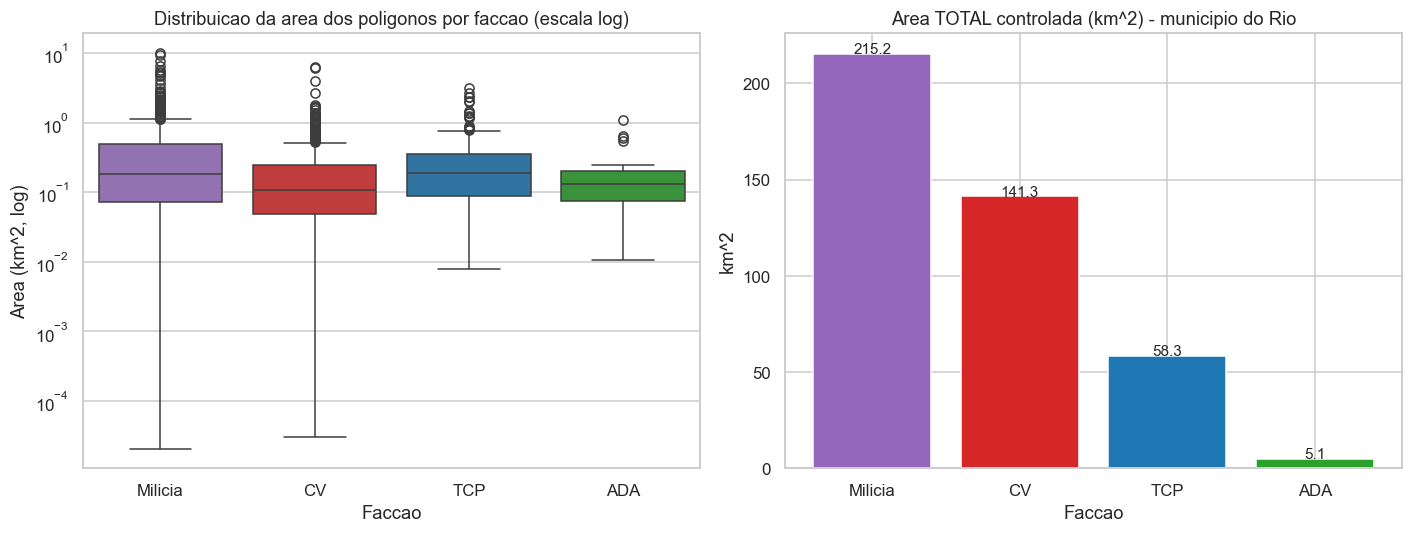

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = by_fac.index.tolist()
palette = [FACTION_COLORS.get(f, '#888') for f in order]

# Boxplot - distribution of polygon sizes
sns.boxplot(data=gdf_rio, x='dominio_orcrim', y='area_km2',
            order=order, palette=palette, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Distribuicao da area dos poligonos por faccao (escala log)')
axes[0].set_xlabel('Faccao'); axes[0].set_ylabel('Area (km^2, log)')

# Total km2 controlled
axes[1].bar(order, by_fac['total_km2'], color=palette)
for i, v in enumerate(by_fac['total_km2']):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=10)
axes[1].set_title('Area TOTAL controlada (km^2) - municipio do Rio')
axes[1].set_xlabel('Faccao'); axes[1].set_ylabel('km^2')
plt.tight_layout(); plt.show()


## 6. Mapa - dominio das faccoes na cidade do Rio + areas da Forca Municipal

Preenchimento por cor da faccao. As 8 areas da Forca Municipal sao sobrepostas em linha grossa preta, com rotulos.

In [11]:
fm = gpd.read_file(SHP_PATH).to_crs(epsg=4326)
print('Areas FM:', len(fm))
print('Colunas FM:', list(fm.columns))
fm.head()


Areas FM: 8
Colunas FM: ['fid', 'nome_subar', 'geometry']


,fid,nome_subar,geometry
0,2.0,Rodoviária - Terminal Gentileza - Estação Leopoldina,"POLYGON ((-43.21251 -22.89815, -43.21289 -22.89746, -43.2121 -22.8969, -43.21071 -22.89836, -43.2099 -22.89838, -43.20006 -22.8943, -43.1991 -22.89502, -43.19983 -22.89512, -43.20024 -22.89528, -43.2008 -22.89551, -43.20129 -22.89586, -43.20715 -22.89837, -43.20785 -22.8992, -43.20835 -22.90016, -43.20821 -22.90363, -43.20808 -22.9047, -43.2081 -22.90521, -43.20838 -22.9057, -43.20878 -22.90612, -43.20935 -22.90642, -43.20919 -22.90927, -43.20895 -22.90975, -43.20837 -22.90991, -43.20758 -22.90999, -43.20673 -22.90975, -43.20573 -22.90931, -43.20542 -22.90933, -43.20428 -22.90901, -43.2018 -22.90821, -43.20004 -22.90772, -43.19868 -22.90722, -43.19906 -22.90704, -43.19917 -22.90677, -43.19915 -22.90649, -43.19899 -22.90629, -43.19868 -22.90615, -43.19842 -22.9061, -43.19817 -22.90616, -43.198 -22.90625, -43.19785 -22.9064, -43.19775 -22.90634, -43.19777 -22.90618, -43.19771 -22.90606, -43.19756 -22.90584, -43.19727 -22.90571, -43.19693 -22.90565, -43.1966 -22.90572, -43.19649 -22.90587, -43.19644 -22.90604, -43.19642 -22.90632, -43.19672 -22.90662, -43.19748 -22.90688, -43.19697 -22.90834, -43.19605 -22.91044, -43.1956 -22.91105, -43.19534 -22.9117, -43.19932 -22.91246, -43.20066 -22.91273, -43.20151 -22.91289, -43.20217 -22.91298, -43.20279 -22.91328, -43.20318 -22.91328, -43.20352 -22.91354, -43.2044 -22.91417, -43.20526 -22.91438, -43.20647 -22.91468, -43.20707 -22.915, -43.20753 -22.91527, -43.20861 -22.91603, -43.21022 -22.91696, -43.21027 -22.91602, -43.21033 -22.91507, -43.21028 -22.91411, -43.21022 -22.91315, -43.21007 -22.91273, -43.20964 -22.91152, -43.20876 -22.91081, -43.20954 -22.91039, -43.21009 -22.90935, -43.21038 -22.90712, -43.21306 -22.90734, -43.21354 -22.90698, -43.21395 -22.90665, -43.21412 -22.90582, -43.21559 -22.90352, -43.21524 -22.9034, -43.21401 -22.9029, -43.21308 -22.90248, -43.21058 -22.90154, -43.21061 -22.90079, -43.2107 -22.90047, -43.21147 -22.8998, -43.21249 -22.89893, -43.21251 -22.89815))"
1,9.0,Metrô Botafogo - Rua São Clemente - Rua Voluntários da Pátria,"POLYGON ((-43.19636 -22.9525, -43.19578 -22.95207, -43.19542 -22.95181, -43.19503 -22.95156, -43.19429 -22.95119, -43.19374 -22.95089, -43.19303 -22.95055, -43.19296 -22.95052, -43.19277 -22.95047, -43.19255 -22.95042, -43.19154 -22.95014, -43.19081 -22.94996, -43.18984 -22.94974, -43.18888 -22.94952, -43.18873 -22.94952, -43.18724 -22.94948, -43.18612 -22.94943, -43.18507 -22.94935, -43.18426 -22.94927, -43.18382 -22.94923, -43.18313 -22.94916, -43.18272 -22.94911, -43.18253 -22.94908, -43.18237 -22.9491, -43.18224 -22.94914, -43.18205 -22.94916, -43.18182 -22.94975, -43.18171 -22.95005, -43.18156 -22.95045, -43.18144 -22.95065, -43.18157 -22.95082, -43.1819 -22.9511, -43.18225 -22.95137, -43.18258 -22.95158, -43.1834 -22.95196, -43.18393 -22.95219, -43.18424 -22.95234, -43.18533 -22.95329, -43.18595 -22.95387, -43.1865 -22.95428, -43.18739 -22.95469, -43.18886 -22.95536, -43.18992 -22.95584, -43.19007 -22.95589, -43.19197 -22.95675, -43.19278 -22.95709, -43.19344 -22.95731, -43.19444 -22.95766, -43.19475 -22.9568, -43.19527 -22.95529, -43.19562 -22.9544, -43.1962 -22.95286, -43.1962 -22.95272, -43.19636 -22.9525))"
2,10.0,Jardim de Alah,"POLYGON ((-43.21838 -22.98006, -43.21846 -22.97898, -43.21816 -22.97887, -43.21797 -22.97887, -43.21783 -22.97894, -43.21749 -22.97922, -43.21734 -22.97931, -43.2162 -22.97991, -43.21459 -22.98045, -43.21326 -22.98051, -43.21324 -22.9808, -43.21334 -22.98222, -43.21341 -22.98331, -43.21351 -22.98489, -43.21357 -22.98589, -43.21345 -22.98617, -43.21432 -22.9862, -43.21459 -22.98621, -43.21573 -22.98632, -43.21749 -22.98654, -43.21772 -22.98519, -43.2179 -22.98362, -43.21816 -22.98138, -43.21838 -22.98006))"
3,11.0,Campo Grande: Estação de Trem - Calçadão,"POLYGON ((-43.56256 -22.90247, -43.56289 -22.9011, -43.56318 -22.89988, -43.5625 -22.89972, -43.56135 -22.89946, -43.56059 -22.89922, -43.55904 -22.89881, -43.55889 -

Coluna de nome FM: nome_subar
Areas FM (nomes): ['Rodoviária - Terminal Gentileza - Estação Leopoldina', 'Metrô Botafogo - Rua São Clemente - Rua Voluntários da Pátria', 'Jardim de Alah', 'Campo Grande: Estação de Trem - Calçadão', 'Rio Sul', 'Praia de Botafogo - Rua Marquês de Abrantes', 'Estações São Francisco Xavier - Afonso Pena', 'Presidente Vargas - Campo de Santana - Central do Brasil - Cinelândia']


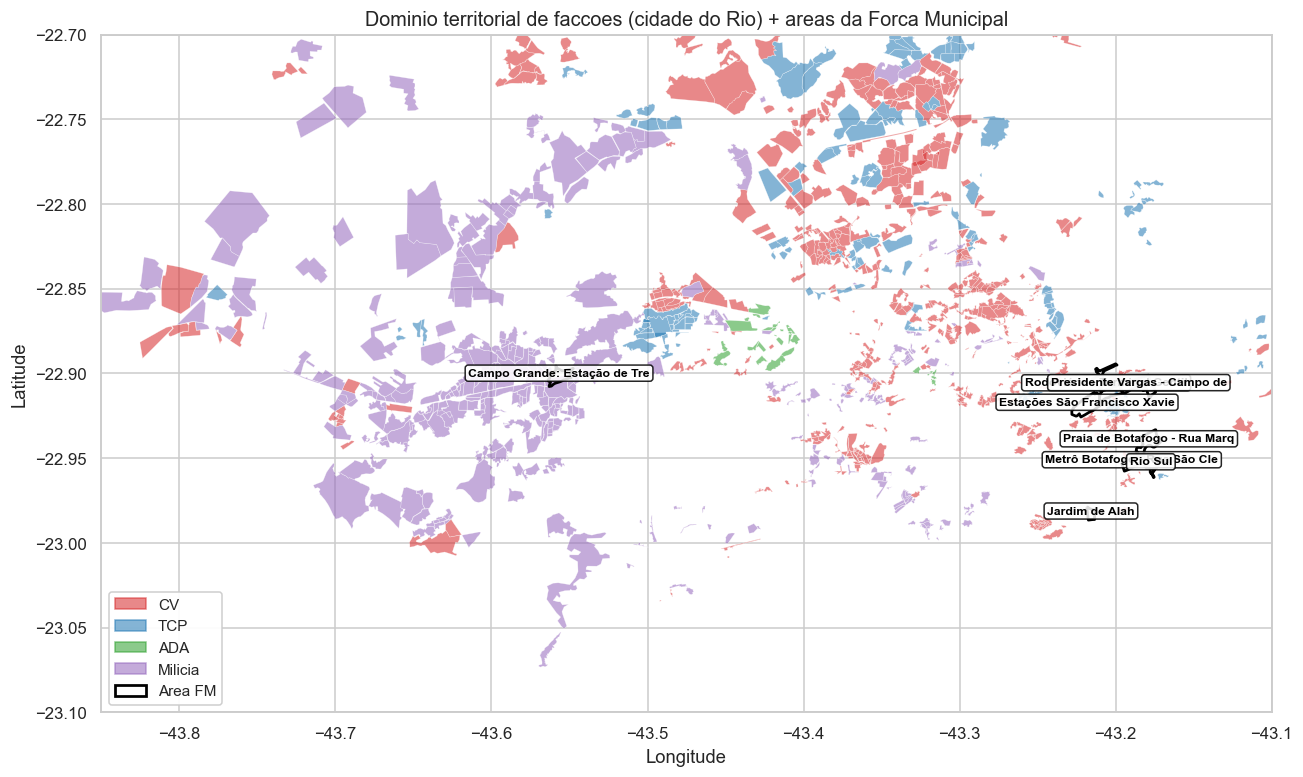

In [12]:
# Identify a name column in the FM layer (prefer obvious name-like columns)
fm_name_col = None
for preferred in ['nome_subar', 'nome', 'name', 'NOME']:
    if preferred in fm.columns:
        fm_name_col = preferred; break
if fm_name_col is None:
    for c in fm.columns:
        if c == 'geometry':
            continue
        if fm[c].map(lambda v: isinstance(v, str)).all():
            fm_name_col = c; break
if fm_name_col is None:
    fm_name_col = [c for c in fm.columns if c != 'geometry'][0]
print('Coluna de nome FM:', fm_name_col)
print('Areas FM (nomes):', list(fm[fm_name_col].astype(str).values))

fig, ax = plt.subplots(figsize=(12, 10))

# Plot each faction
for fac, color in FACTION_COLORS.items():
    sub = gdf_rio[gdf_rio['dominio_orcrim'] == fac]
    if len(sub) == 0:
        continue
    sub.plot(ax=ax, color=color, alpha=0.55, edgecolor='white', linewidth=0.3)

# Overlay FM boundaries in bold
fm.boundary.plot(ax=ax, color='black', linewidth=1.8)

# Label FM polygons
for _, row in fm.iterrows():
    c = row.geometry.centroid
    ax.annotate(str(row[fm_name_col])[:28], (c.x, c.y),
                fontsize=8, ha='center', color='black', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='black', alpha=0.85))

ax.set_xlim(RIO_BBOX['minx'], RIO_BBOX['maxx'])
ax.set_ylim(RIO_BBOX['miny'], RIO_BBOX['maxy'])
ax.set_title('Dominio territorial de faccoes (cidade do Rio) + areas da Forca Municipal',
             fontsize=13)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

# Legend
handles = [mpatches.Patch(color=c, label=f, alpha=0.55) for f, c in FACTION_COLORS.items()]
handles.append(mpatches.Patch(facecolor='none', edgecolor='black', linewidth=1.8, label='Area FM'))
ax.legend(handles=handles, loc='lower left', fontsize=10, framealpha=0.95)

plt.tight_layout(); plt.show()


## 7. Intersecao: faccao x area da Forca Municipal

Para cada poligono FM, calculamos a area (km^2) interceptada por cada faccao. A tabela resultante (linhas = areas FM, colunas = faccoes) e o **insight mais acionavel** desta camada: mostra quais areas FM estao em territorio dominado por qual faccao, e quais sao fronteiras (mistura de faccoes => area quente).

In [13]:
# Reproject both layers to metric CRS for accurate intersection
fm_m   = fm[[fm_name_col, 'geometry']].rename(columns={fm_name_col: 'area_fm'}).to_crs(epsg=31983)
gdf_m  = gdf_rio[['dominio_orcrim', 'geometry']].to_crs(epsg=31983)

inter = gpd.overlay(fm_m, gdf_m, how='intersection', keep_geom_type=True)
inter['area_km2'] = inter.geometry.area / 1e6

cross = (inter.groupby(['area_fm', 'dominio_orcrim'])['area_km2']
              .sum().unstack(fill_value=0.0).round(3))
cross['TOTAL_km2'] = cross.sum(axis=1).round(3)
cross = cross.sort_values('TOTAL_km2', ascending=False)
cross


dominio_orcrim,CV,Milicia,TCP,TOTAL_km2
area_fm,,,,
Campo Grande: Estação de Trem - Calçadão,0.000,0.457,0.000,0.457
Rodoviária - Terminal Gentileza - Estação Leopoldina,0.000,0.000,0.054,0.054
Praia de Botafogo - Rua Marquês de Abrantes,0.045,0.000,0.000,0.045
Jardim de Alah,0.013,0.000,0.000,0.013


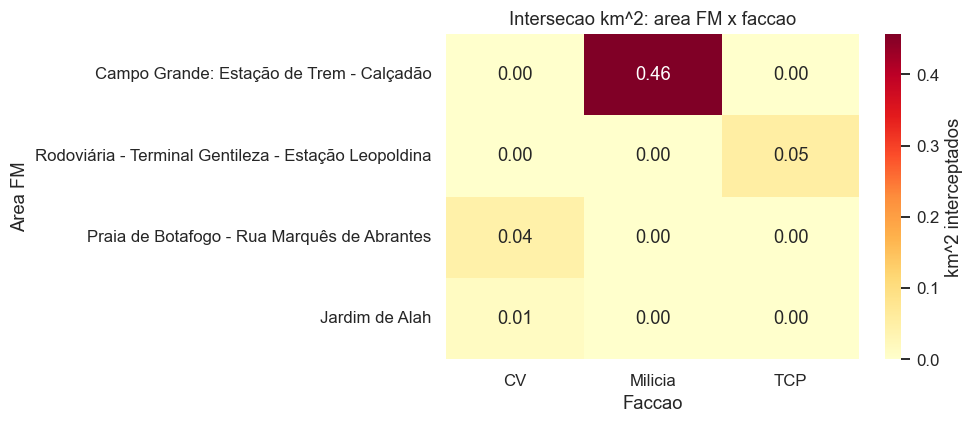

In [14]:
# Heatmap of intersection areas
plot_df = cross.drop(columns=['TOTAL_km2'])
fig, ax = plt.subplots(figsize=(9, max(4, 0.5 * len(plot_df))))
sns.heatmap(plot_df, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'km^2 interceptados'})
ax.set_title('Intersecao km^2: area FM x faccao')
ax.set_xlabel('Faccao'); ax.set_ylabel('Area FM')
plt.tight_layout(); plt.show()


In [15]:
# Share (%) of each FM area covered by each faction
share = plot_df.div(plot_df.sum(axis=1).replace(0, np.nan), axis=0).mul(100).round(1).fillna(0)
share['DOMINANTE'] = plot_df.idxmax(axis=1)
share['mix_score'] = (1 - (plot_df.max(axis=1) / plot_df.sum(axis=1).replace(0, np.nan))).round(2).fillna(0)
share = share.sort_values('mix_score', ascending=False)
print('mix_score = 0 => uma faccao domina; mix_score alto => FRONTEIRA (varias faccoes presentes).')
share


mix_score = 0 => uma faccao domina; mix_score alto => FRONTEIRA (varias faccoes presentes).


dominio_orcrim,CV,Milicia,TCP,DOMINANTE,mix_score
area_fm,,,,,
Campo Grande: Estação de Trem - Calçadão,0.0,100.0,0.0,Milicia,0.0
Rodoviária - Terminal Gentileza - Estação Leopoldina,0.0,0.0,100.0,TCP,0.0
Praia de Botafogo - Rua Marquês de Abrantes,100.0,0.0,0.0,CV,0.0
Jardim de Alah,100.0,0.0,0.0,CV,0.0


**Como ler a tabela acima:**
- `DOMINANTE` = faccao com maior area interceptada naquele setor FM.
- `mix_score` proximo de 0 => area homogenea (uma faccao domina). Score alto => **fronteira faccional** = area com risco elevado de confronto/disputa.

## 8. Top 10 territorios nomeados por area (cidade do Rio)

Lista os 10 maiores poligonos nomeados dentro do municipio. Util pra identificar grandes complexos faccionais.

In [16]:
top10 = (gdf_rio[['nome_territorio', 'dominio_orcrim', 'area_km2']]
          .sort_values('area_km2', ascending=False)
          .head(10)
          .reset_index(drop=True))
top10


,nome_territorio,dominio_orcrim,area_km2
0,CHAPERÓ - ITAGUAÍ,Milicia,9.919986
1,KM40,Milicia,9.189477
2,SEPETIBA,Milicia,7.702905
3,ILHA DE GUARATIBA,Milicia,6.458758
4,CARMARI,CV,6.233459
5,WEDA,CV,6.054153
6,CABUÇU,Milicia,5.606813
7,SANTISSIMO,Milicia,5.248179
8,CAMPO LINDO,Milicia,5.184781
9,CAROBINHA,Milicia,4.763776


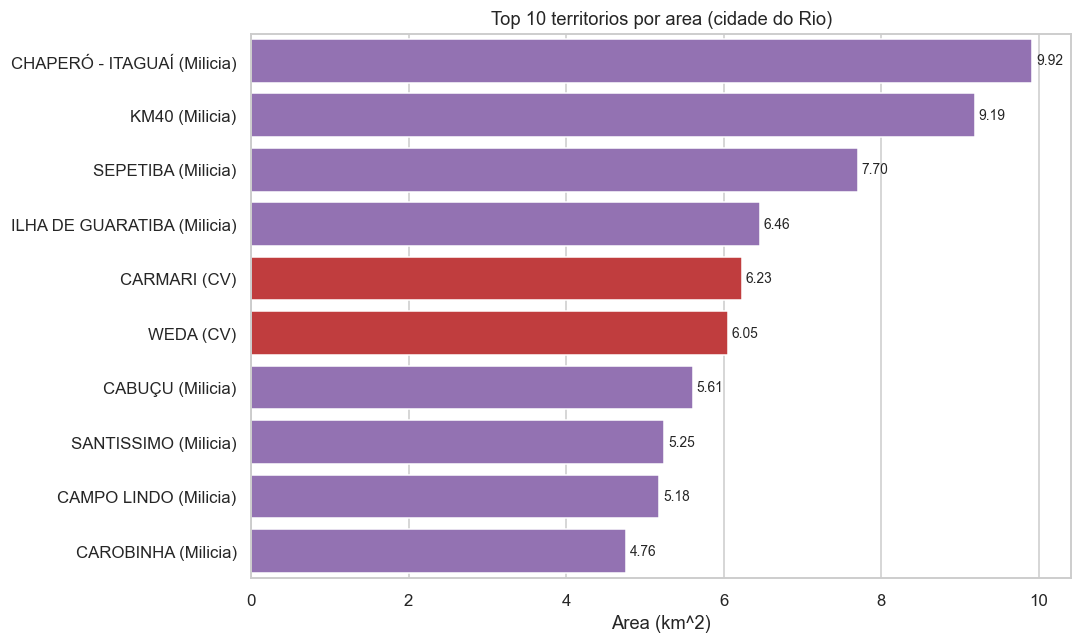

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = [FACTION_COLORS.get(f, '#888') for f in top10['dominio_orcrim']]
labels = [f"{n} ({f})" for n, f in zip(top10['nome_territorio'], top10['dominio_orcrim'])]
sns.barplot(y=labels, x=top10['area_km2'], ax=ax, palette=colors, orient='h')
for i, v in enumerate(top10['area_km2']):
    ax.text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=9)
ax.set_title('Top 10 territorios por area (cidade do Rio)')
ax.set_xlabel('Area (km^2)'); ax.set_ylabel('')
plt.tight_layout(); plt.show()


## 9. Conclusoes

1. **Recorte estadual vs municipal.** Dos 1.628 poligonos, **1.164 (71,5%)** caem no bbox do municipio do Rio. Os 464 restantes estao espalhados pelo estado - principalmente Norte Fluminense (onde ADA tem forte presenca: so 33% dos poligonos de ADA estao no Rio, contra 92% dos poligonos de Milicia). Filtrar pelo bbox antes de cruzar com FM e obrigatorio.

2. **Milicia controla 1,5x mais km^2 que CV no municipio do Rio.** Numeros do recorte municipal: Milicia = 215 km^2 (391 poligonos), CV = 141 km^2 (583 poligonos), TCP = 58 km^2, ADA = 5 km^2. Apesar de CV ter MAIS poligonos, sao geograficamente menores (mediana 0,11 km^2 vs 0,18 km^2 da Milicia) - reflete a geografia: CV opera em complexos densos da Zona Norte (Alemao, Penha, Mare); Milicia ocupa areas contiguas e grandes na Zona Oeste (Bangu, Campo Grande, Santa Cruz). **Area NAO e proxy de volume de crime** - so de territorio fisico.

3. **Maioria das areas FM NAO esta sobre territorio faccional mapeado.** Das 8 areas FM, **apenas 4 interceptam algum poligono faccional** (Campo Grande, Rodoviaria-Gentileza, Praia de Botafogo, Jardim de Alah). As outras 4 (Cinelandia, Metro Botafogo, Rio Sul, Sao Francisco Xavier/Afonso Pena) sao zonas centrais/formais sem dominio faccional cartografado. Isso e tanto resultado real (centro do Rio e mais "formal") quanto provavel limitacao da camada (cobertura prioriza favelas/comunidades).

4. **Nas 4 areas FM que interceptam, NAO ha fronteiras faccionais.** Todas as 4 areas com sobreposicao tem `mix_score = 0` - cada uma toca **uma unica faccao**:
   - **Campo Grande - Estacao/Calcadao**: 100% Milicia (0,46 km^2 intersectados).
   - **Rodoviaria - Gentileza - Leopoldina**: 100% TCP (0,05 km^2).
   - **Praia de Botafogo - Marques de Abrantes**: 100% CV (0,05 km^2).
   - **Jardim de Alah**: 100% CV (0,01 km^2).
   Operacionalmente isso significa: a abordagem em cada area FM precisa ser calibrada para o adversario especifico - **nao ha disputas territoriais ativas dentro do perimetro FM**, mas as bordas dessas areas (Campo Grande, em particular) sao potenciais zonas de tensao com territorios faccionais vizinhos.

5. **Top 10 territorios sao 80% Milicia da Zona Oeste** - Chapero/Itaguai (9,9 km^2), KM40 (9,2 km^2), Sepetiba (7,7 km^2). Os dois CV no top 10 (CARMARI, WEDA) sao tambem na Zona Oeste, refletindo o avanco do CV em areas tradicionalmente milicianas.

**Insumo para o Desafio Extra 2 (migracao do crime):** quando uma operacao policial pressiona um setor, a hipotese natural e migracao para poligonos vizinhos **da mesma faccao** (a faccao gerencia mercado/protecao em toda sua malha). Esta camada permite (a) construir grafo de adjacencia faccional, (b) prever vetores de deslocamento esperado pos-operacao, (c) identificar fronteiras inter-faccionais como hotspots latentes de confronto.

**Proximos passos:**
- Cruzar este mapa de dominio com `01_ocorrencias.ipynb` - testar se mix/volume de delitos varia entre territorios CV vs Milicia.
- Calcular adjacencia entre poligonos faccionais e identificar **fronteiras inter-faccionais** (CV-Milicia, CV-TCP) - candidatos a hotspots de confronto.
- Construir indice composto de risco por celula H3: dominio faccional + presenca de FM + volume de ocorrencias.
